# Tugas 1 — Scraping Berita Detik.com Kategori Sport dan Finance

Notebook ini digunakan untuk melakukan pencarian dan penambangan data berita dari website Detik.com.

Data yang dikumpulkan terdiri dari dua kategori berita, yaitu:

- Sport
- Finance

Target pengumpulan data adalah 100 artikel dari kategori Sport dan 100 artikel dari kategori Finance sehingga diperoleh maksimal 200 artikel.

Proses scraping meliputi:

1. Pengumpulan URL artikel.
2. Validasi URL.
3. Ekstraksi isi artikel menggunakan Trafilatura.
4. Penyimpanan dataset berdasarkan kategori.
5. Penggabungan dataset Sport dan Finance.
6. Pemeriksaan kualitas dataset.
7. Analisis statistik sederhana terhadap corpus berita.

## 1. Alat dan Library

Library yang digunakan dalam proses scraping adalah:

- `requests` untuk melakukan HTTP request.
- `BeautifulSoup4` untuk membaca dan menganalisis struktur HTML.
- `trafilatura` untuk mengekstraksi teks utama artikel.
- `pandas` untuk mengolah dataset.
- `tqdm` untuk menampilkan progress bar.
- `time` untuk memberikan jeda antar-request.
- `re` untuk validasi pola URL.
- `urllib.parse` untuk melakukan normalisasi dan pemeriksaan URL.

In [1]:
!pip install -q requests beautifulsoup4 trafilatura pandas tqdm openpyxl

In [2]:
import requests
from bs4 import BeautifulSoup
import trafilatura
import pandas as pd
import time
import re
import os

from tqdm import tqdm
from urllib.parse import urljoin, urlsplit, urlunsplit
from datetime import datetime

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


## 2. Konfigurasi Scraping

Sumber data berasal dari:

- Detik Sport
- Detik Finance

Masing-masing kategori ditargetkan sebanyak 100 artikel.

URL artikel akan dikumpulkan terlebih dahulu sebelum dilakukan proses ekstraksi teks.

In [3]:
BASE_URL_SPORT = "https://sport.detik.com/"
BASE_URL_FINANCE = "https://finance.detik.com/"

TARGET_ARTICLES = 100
MAX_PAGES = 50

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/154.0.0.0 Safari/537.36"
    )
}

REQUEST_DELAY = 1.0

print("Konfigurasi scraping berhasil dibuat.")
print("Target Sport   :", TARGET_ARTICLES)
print("Target Finance :", TARGET_ARTICLES)
print("Maksimum halaman:", MAX_PAGES)

Konfigurasi scraping berhasil dibuat.
Target Sport   : 100
Target Finance : 100
Maksimum halaman: 50


## 3. Session HTTP

Session digunakan agar koneksi HTTP dapat digunakan kembali selama proses scraping.

User-Agent digunakan agar request memiliki informasi client yang wajar ketika mengakses website.

In [4]:
session = requests.Session()
session.headers.update(HEADERS)

print("HTTP Session berhasil dibuat.")

HTTP Session berhasil dibuat.


## 4. Normalisasi URL

URL yang ditemukan dari halaman indeks dinormalisasi agar URL yang sama dengan query parameter atau fragment berbeda tidak dianggap sebagai artikel yang berbeda.

Normalisasi dilakukan dengan mempertahankan:

- scheme
- netloc
- path

sedangkan query dan fragment dihilangkan.

In [5]:
def normalize_url(url):
    try:
        parts = urlsplit(url)

        return urlunsplit(
            (
                parts.scheme.lower(),
                parts.netloc.lower(),
                parts.path.rstrip("/"),
                "",
                ""
            )
        )
    except Exception:
        return None

## 5. Validasi URL Artikel

URL yang digunakan harus memenuhi beberapa kondisi:

- menggunakan HTTP atau HTTPS;
- berasal dari domain Detik yang sesuai;
- memiliki pola URL artikel;
- bukan halaman foto;
- bukan halaman video;
- belum pernah dikumpulkan sebelumnya.

Validasi ini digunakan untuk mengurangi kemungkinan URL yang tidak sesuai masuk ke dataset.

In [6]:
def valid_article_url(url, base_url):
    if not url:
        return False

    normalized = normalize_url(url)

    if not normalized:
        return False

    parsed = urlsplit(normalized)
    base_parsed = urlsplit(base_url)

    if parsed.scheme not in ["http", "https"]:
        return False

    if parsed.netloc != base_parsed.netloc:
        return False

    if "foto" in parsed.path.lower():
        return False

    if "video" in parsed.path.lower():
        return False

    if not re.search(r"/d-\d+", parsed.path):
        return False

    return True

## 6. Mengumpulkan URL Artikel

Pengumpulan URL dilakukan melalui halaman indeks kategori.

Proses dilakukan secara bertahap berdasarkan pagination `?page=`.

URL yang telah ditemukan disimpan dalam list dan duplikasi dihindari.

In [7]:
def dapatkan_url_detik(url_dasar, target_jumlah=100):
    url_list = []
    url_set = set()
    halaman = 1

    print(f"Mulai mencari artikel dari: {url_dasar}")

    with tqdm(total=target_jumlah, desc="Mengumpulkan URL") as pbar:

        while len(url_list) < target_jumlah and halaman <= MAX_PAGES:

            url_indeks = f"{url_dasar}indeks?page={halaman}"

            try:
                response = session.get(
                    url_indeks,
                    timeout=15
                )

                if response.status_code != 200:
                    print(
                        f"\nPeringatan: status {response.status_code} "
                        f"pada halaman {halaman}"
                    )
                    halaman += 1
                    time.sleep(REQUEST_DELAY)
                    continue

                soup = BeautifulSoup(
                    response.text,
                    "html.parser"
                )

                artikel_elemen = soup.find_all("article")

                if not artikel_elemen:
                    print(
                        f"\nTidak menemukan elemen artikel "
                        f"pada halaman {halaman}."
                    )
                    halaman += 1
                    time.sleep(REQUEST_DELAY)
                    continue

                jumlah_sebelum = len(url_list)

                for artikel in artikel_elemen:

                    link = None

                    if artikel.has_attr("i-link"):
                        link = artikel.get("i-link")

                    if not link:
                        tag_a = artikel.find("a", href=True)

                        if tag_a:
                            link = tag_a.get("href")

                    if link:
                        link = urljoin(
                            url_dasar,
                            link
                        )

                        link = normalize_url(link)

                    if (
                        valid_article_url(
                            link,
                            url_dasar
                        )
                        and link not in url_set
                    ):
                        url_set.add(link)
                        url_list.append(link)
                        pbar.update(1)

                    if len(url_list) >= target_jumlah:
                        break

                if len(url_list) == jumlah_sebelum:
                    print(
                        f"\nTidak ada URL baru pada halaman {halaman}."
                    )

                halaman += 1
                time.sleep(REQUEST_DELAY)

            except requests.RequestException as e:
                print(
                    f"\nGagal mengakses halaman {halaman}: {e}"
                )
                halaman += 1
                time.sleep(REQUEST_DELAY)

            except Exception as e:
                print(
                    f"\nTerjadi kesalahan pada halaman {halaman}: {e}"
                )
                halaman += 1
                time.sleep(REQUEST_DELAY)

    print(
        f"\nURL berhasil dikumpulkan: {len(url_list)}"
    )

    return url_list

## 7. Mengumpulkan URL Sport dan Finance

In [8]:
url_sport = dapatkan_url_detik(
    BASE_URL_SPORT,
    TARGET_ARTICLES
)

print("\n" + "=" * 60)

url_finance = dapatkan_url_detik(
    BASE_URL_FINANCE,
    TARGET_ARTICLES
)

print("\n=== HASIL PENGUMPULAN URL ===")
print("URL Sport   :", len(url_sport))
print("URL Finance :", len(url_finance))

Mulai mencari artikel dari: https://sport.detik.com/


Mengumpulkan URL: 100%|█| 100/100 [00:08<0



URL berhasil dikumpulkan: 100

Mulai mencari artikel dari: https://finance.detik.com/


Mengumpulkan URL: 100%|█| 100/100 [00:07<0


URL berhasil dikumpulkan: 100

=== HASIL PENGUMPULAN URL ===
URL Sport   : 100
URL Finance : 100


## 8. Pemeriksaan URL Sebelum Ekstraksi

Sebelum mengambil isi artikel, dilakukan pemeriksaan terhadap URL yang berhasil dikumpulkan.

Pemeriksaan meliputi:

- jumlah URL;
- URL duplikat;
- URL kosong;
- domain URL;
- distribusi kategori.

In [9]:
def periksa_url(url_list, nama_kategori, base_url):
    df_url = pd.DataFrame({
        "url": url_list
    })

    print(f"=== PEMERIKSAAN URL {nama_kategori.upper()} ===")
    print("Jumlah URL :", len(df_url))
    print("URL kosong :", df_url["url"].isna().sum())
    print("URL duplikat :", df_url["url"].duplicated().sum())

    domain_valid = df_url["url"].apply(
        lambda x: (
            isinstance(x, str)
            and urlsplit(x).netloc == urlsplit(base_url).netloc
        )
    )

    print("URL dengan domain valid :", domain_valid.sum())

    return df_url


df_url_sport = periksa_url(
    url_sport,
    "sport",
    BASE_URL_SPORT
)

print()

df_url_finance = periksa_url(
    url_finance,
    "finance",
    BASE_URL_FINANCE
)

=== PEMERIKSAAN URL SPORT ===
Jumlah URL : 100
URL kosong : 0
URL duplikat : 0
URL dengan domain valid : 100

=== PEMERIKSAAN URL FINANCE ===
Jumlah URL : 100
URL kosong : 0
URL duplikat : 0
URL dengan domain valid : 100


## 9. Ekstraksi Isi Artikel

Isi artikel diekstraksi menggunakan Trafilatura.

Trafilatura digunakan untuk memperoleh teks utama artikel dan mengurangi elemen non-konten dari halaman web.

Artikel yang gagal diunduh atau tidak menghasilkan teks tidak dimasukkan ke dataset.

In [10]:
def bersihkan_teks(teks):
    if not teks:
        return None

    teks = str(teks)

    teks = re.sub(
        r"\s+",
        " ",
        teks
    ).strip()

    teks = re.sub(
        r"ADVERTISEMENT",
        " ",
        teks,
        flags=re.IGNORECASE
    )

    teks = re.sub(
        r"SCROLL TO CONTINUE WITH CONTENT",
        " ",
        teks,
        flags=re.IGNORECASE
    )

    teks = re.sub(
        r"\s+",
        " ",
        teks
    ).strip()

    return teks if teks else None

In [11]:
def ekstrak_teks_trafilatura(
    url_list,
    kategori,
    delay=REQUEST_DELAY
):
    data_ekstrak = []

    for url in tqdm(
        url_list,
        desc=f"Ekstraksi teks {kategori}"
    ):

        try:
            downloaded = trafilatura.fetch_url(url)

            if downloaded:
                teks = trafilatura.extract(
                    downloaded
                )

                teks_bersih = bersihkan_teks(
                    teks
                )

                if (
                    teks_bersih
                    and len(teks_bersih) >= 100
                ):
                    data_ekstrak.append({
                        "kategori": kategori,
                        "url": url,
                        "teks": teks_bersih
                    })

        except Exception as e:
            print(
                f"\nGagal mengekstrak {url}: {e}"
            )

        time.sleep(delay)

    return data_ekstrak

## 10. Melakukan Ekstraksi Artikel

In [12]:
data_sport = ekstrak_teks_trafilatura(
    url_sport,
    "sport"
)

data_finance = ekstrak_teks_trafilatura(
    url_finance,
    "finance"
)

print("\n=== HASIL EKSTRAKSI ===")
print("Artikel Sport berhasil   :", len(data_sport))
print("Artikel Finance berhasil :", len(data_finance))

Ekstraksi teks sport: 100%|█| 100/100 [02:
Ekstraksi teks finance: 100%|█| 100/100 [0


=== HASIL EKSTRAKSI ===
Artikel Sport berhasil   : 100
Artikel Finance berhasil : 100


## 11. Validasi Hasil Ekstraksi

Jumlah artikel yang berhasil diekstraksi dapat berbeda dari jumlah URL yang dikumpulkan karena terdapat kemungkinan kegagalan download atau ekstraksi.

Oleh karena itu, jumlah artikel hasil ekstraksi harus diperiksa sebelum dataset dibentuk.

In [13]:
print("=== PERBANDINGAN URL DAN HASIL EKSTRAKSI ===")

print(
    f"Sport   : {len(url_sport)} URL "
    f"→ {len(data_sport)} artikel berhasil"
)

print(
    f"Finance : {len(url_finance)} URL "
    f"→ {len(data_finance)} artikel berhasil"
)

print(
    f"Total   : {len(url_sport) + len(url_finance)} URL "
    f"→ {len(data_sport) + len(data_finance)} artikel berhasil"
)

=== PERBANDINGAN URL DAN HASIL EKSTRAKSI ===
Sport   : 100 URL → 100 artikel berhasil
Finance : 100 URL → 100 artikel berhasil
Total   : 200 URL → 200 artikel berhasil


## 12. Membentuk Dataset Sport dan Finance

Hasil ekstraksi masing-masing kategori diubah menjadi DataFrame.

Setiap dataset memiliki tiga kolom:

- `kategori`
- `url`
- `teks`

In [14]:
df_sport = pd.DataFrame(
    data_sport
)

df_finance = pd.DataFrame(
    data_finance
)

print("=== DATASET SPORT ===")
print("Jumlah baris :", len(df_sport))
print("Jumlah kolom :", len(df_sport.columns))
display(df_sport.head(3))

print("\n=== DATASET FINANCE ===")
print("Jumlah baris :", len(df_finance))
print("Jumlah kolom :", len(df_finance.columns))
display(df_finance.head(3))

=== DATASET SPORT ===
Jumlah baris : 100
Jumlah kolom : 3


,kategori,url,teks
0,sport,https://sport.detik.com/sport-lain/d-8695603/e...,Menpora Erick Thohir senang kontingen Indonesi...
1,sport,https://sport.detik.com/moto-gp/d-8695608/moto...,Rangkaian seri balap MotoGP Jepang di Sirkuit ...
2,sport,https://sport.detik.com/moto-gp/d-8695361/impi...,Jorge Martin sedang memperjuangkan titel juara...



=== DATASET FINANCE ===
Jumlah baris : 100
Jumlah kolom : 3


,kategori,url,teks
0,finance,https://finance.detik.com/berita-ekonomi-bisni...,"Sebanyak 33,2 juta warga bakal mendapat bantua..."
1,finance,https://finance.detik.com/berita-ekonomi-bisni...,Perluas akses inklusi keuangan dan memberikan ...
2,finance,https://finance.detik.com/infrastruktur/d-8695...,KAI Properti terus mempercepat penyelesaian pe...


## 13. Menyimpan Dataset Per Kategori

In [15]:
os.makedirs("data", exist_ok=True)

file_sport = "data/dataset_detik_sport.csv"
file_finance = "data/dataset_detik_finance.csv"

df_sport.to_csv(
    file_sport,
    index=False,
    encoding="utf-8"
)

df_finance.to_csv(
    file_finance,
    index=False,
    encoding="utf-8"
)

print("Dataset Sport berhasil disimpan :", file_sport)
print("Dataset Finance berhasil disimpan :", file_finance)

Dataset Sport berhasil disimpan : data/dataset_detik_sport.csv
Dataset Finance berhasil disimpan : data/dataset_detik_finance.csv


## 14. Menggabungkan Dataset

Dataset Sport dan Finance digabungkan menjadi satu dataset.

Dataset gabungan akan digunakan sebagai dataset utama untuk tahap pengolahan selanjutnya.

In [16]:
df_all = pd.concat(
    [df_sport, df_finance],
    ignore_index=True
)

df_all.insert(
    0,
    "id",
    range(1, len(df_all) + 1)
)

print("=== DATASET GABUNGAN ===")
print("Jumlah baris :", len(df_all))
print("Jumlah kolom :", len(df_all.columns))

display(df_all.head())

=== DATASET GABUNGAN ===
Jumlah baris : 200
Jumlah kolom : 4


,id,kategori,url,teks
0,1,sport,https://sport.detik.com/sport-lain/d-8695603/e...,Menpora Erick Thohir senang kontingen Indonesi...
1,2,sport,https://sport.detik.com/moto-gp/d-8695608/moto...,Rangkaian seri balap MotoGP Jepang di Sirkuit ...
2,3,sport,https://sport.detik.com/moto-gp/d-8695361/impi...,Jorge Martin sedang memperjuangkan titel juara...
3,4,sport,https://sport.detik.com/moto-gp/d-8695022/veda...,Rider Indonesia Veda Ega Pratama balapan di Ma...
4,5,sport,https://sport.detik.com/sport-lain/d-8694792/t...,"Pelatih speed tim panjat tebing, Fitriyani, me..."


## 15. Pemeriksaan Kualitas Dataset

Pemeriksaan dilakukan untuk memastikan dataset hasil scraping memiliki kualitas yang sesuai sebelum digunakan pada tahap preprocessing.

Pemeriksaan meliputi:

- jumlah data;
- nilai kosong;
- duplikasi ID;
- duplikasi URL;
- duplikasi teks;
- distribusi kategori;
- teks kosong;
- teks yang terlalu pendek.

In [17]:
print("=== PEMERIKSAAN KUALITAS DATASET ===")

print("Jumlah artikel Sport   :", len(df_sport))
print("Jumlah artikel Finance :", len(df_finance))
print("Jumlah artikel Total   :", len(df_all))

print("\nMissing value:")
print(df_all.isna().sum())

print("\nDuplikasi ID:")
print(df_all["id"].duplicated().sum())

print("\nDuplikasi URL:")
print(df_all["url"].duplicated().sum())

print("\nDuplikasi teks:")
print(df_all["teks"].duplicated().sum())

print("\nTeks kosong:")
print(
    df_all["teks"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("\nTeks kurang dari 100 karakter:")
print(
    (
        df_all["teks"]
        .astype(str)
        .str.len()
        < 100
    ).sum()
)

print("\nDistribusi kategori:")
print(df_all["kategori"].value_counts())

=== PEMERIKSAAN KUALITAS DATASET ===
Jumlah artikel Sport   : 100
Jumlah artikel Finance : 100
Jumlah artikel Total   : 200

Missing value:
id          0
kategori    0
url         0
teks        0
dtype: int64

Duplikasi ID:
0

Duplikasi URL:
0

Duplikasi teks:
0

Teks kosong:
0

Teks kurang dari 100 karakter:
0

Distribusi kategori:
kategori
sport      100
finance    100
Name: count, dtype: int64


## 16. Validasi Target Dataset

Target dataset adalah:

- 100 artikel Sport
- 100 artikel Finance
- total 200 artikel

Validasi dilakukan untuk memastikan dataset akhir memenuhi target pengumpulan.

In [18]:
jumlah_sport = (
    df_all["kategori"]
    .eq("sport")
    .sum()
)

jumlah_finance = (
    df_all["kategori"]
    .eq("finance")
    .sum()
)

print("=== VALIDASI TARGET ===")
print("Sport   :", jumlah_sport)
print("Finance :", jumlah_finance)
print("Total   :", len(df_all))

if jumlah_sport == 100 and jumlah_finance == 100:
    print("\nTarget dataset 200 artikel tercapai.")
else:
    print("\nTarget 200 artikel belum tercapai.")
    print(
        "Gunakan jumlah artikel aktual sebagai dataset akhir."
    )

=== VALIDASI TARGET ===
Sport   : 100
Finance : 100
Total   : 200

Target dataset 200 artikel tercapai.


## 17. Statistik Jumlah Kata

Jumlah kata dihitung pada setiap artikel berdasarkan pemisahan teks menggunakan spasi.

Statistik ini digunakan untuk mengetahui ukuran corpus yang berhasil dikumpulkan.

In [19]:
df_all["jumlah_kata"] = (
    df_all["teks"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

total_kata = df_all["jumlah_kata"].sum()

print("=== STATISTIK CORPUS TEKS ===")
print("Total dokumen :", len(df_all))
print(f"Total seluruh kata : {total_kata:,}")

display(
    df_all[
        ["id", "kategori", "jumlah_kata", "teks"]
    ].head()
)

=== STATISTIK CORPUS TEKS ===
Total dokumen : 200
Total seluruh kata : 68,169


,id,kategori,jumlah_kata,teks
0,1,sport,279,Menpora Erick Thohir senang kontingen Indonesi...
1,2,sport,228,Rangkaian seri balap MotoGP Jepang di Sirkuit ...
2,3,sport,223,Jorge Martin sedang memperjuangkan titel juara...
3,4,sport,247,Rider Indonesia Veda Ega Pratama balapan di Ma...
4,5,sport,400,"Pelatih speed tim panjat tebing, Fitriyani, me..."


## 18. Statistik Panjang Artikel

In [20]:
print("=== STATISTIK JUMLAH KATA PER ARTIKEL ===")

display(
    df_all["jumlah_kata"].describe()
)

print("\n=== STATISTIK PER KATEGORI ===")

display(
    df_all.groupby("kategori")["jumlah_kata"].agg(
        ["count", "mean", "min", "max"]
    )
)

=== STATISTIK JUMLAH KATA PER ARTIKEL ===


count     200.000000
mean      340.845000
std       176.210162
min        87.000000
25%       231.750000
50%       313.500000
75%       395.250000
max      1759.000000
Name: jumlah_kata, dtype: float64


=== STATISTIK PER KATEGORI ===


,count,mean,min,max
kategori,,,,
finance,100,335.97,94,973
sport,100,345.72,87,1759


## 19. Vocabulary Corpus

Vocabulary dihitung berdasarkan seluruh kata yang terdapat dalam dataset hasil scraping.

Perhitungan ini digunakan sebagai gambaran awal ukuran vocabulary sebelum tahap preprocessing.

In [21]:
semua_teks = " ".join(
    df_all["teks"]
    .astype(str)
    .tolist()
).lower()

kumpulan_kata = semua_teks.split()

kata_unik = set(kumpulan_kata)

jumlah_kata_unik = len(kata_unik)

print("=== VOCABULARY CORPUS ===")
print(
    f"Total kata unik : {jumlah_kata_unik:,}"
)

print("\nContoh vocabulary:")
print(
    list(kata_unik)[:20]
)

=== VOCABULARY CORPUS ===
Total kata unik : 11,997

Contoh vocabulary:
['pecatur,', 'bermunculan', 'placement.', 'zen', '+0.562s', '1.335.000.', 'google', 'perdagangan.', 'belanja.', 'malang,', '17.900).', 'chaehyun', 'separuh', 'utama.', '(tmmin)', '2028', 'menteri', 'utesheva', 'performa', 'syahria']


## 20. Distribusi Kategori

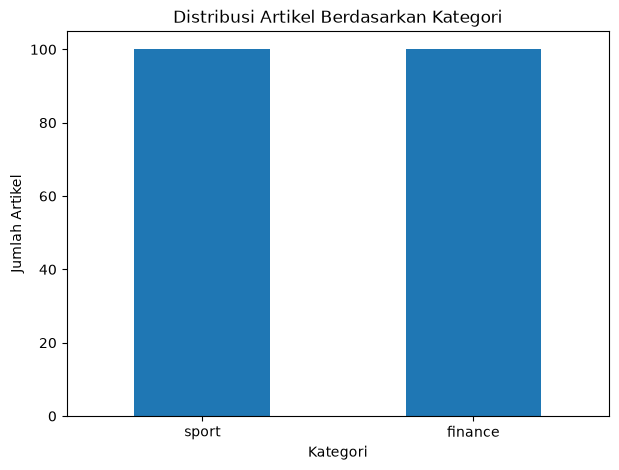

In [22]:
import matplotlib.pyplot as plt

distribusi_kategori = (
    df_all["kategori"]
    .value_counts()
)

plt.figure(figsize=(7, 5))

distribusi_kategori.plot(
    kind="bar"
)

plt.title(
    "Distribusi Artikel Berdasarkan Kategori"
)

plt.xlabel("Kategori")
plt.ylabel("Jumlah Artikel")

plt.xticks(rotation=0)

plt.show()

## 21. Distribusi Jumlah Kata

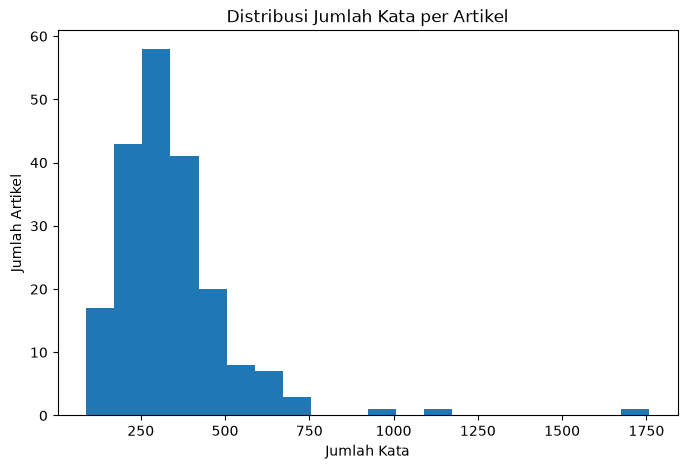

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_all["jumlah_kata"],
    bins=20
)

plt.title(
    "Distribusi Jumlah Kata per Artikel"
)

plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Artikel")

plt.show()

## 22. Sampel Dataset Akhir

Beberapa data ditampilkan sebagai pemeriksaan akhir terhadap hasil scraping.

In [24]:
display(
    df_all[
        [
            "id",
            "kategori",
            "url",
            "jumlah_kata",
            "teks"
        ]
    ].head(10)
)

,id,kategori,url,jumlah_kata,teks
0,1,sport,https://sport.detik.com/sport-lain/d-8695603/e...,279,Menpora Erick Thohir senang kontingen Indonesi...
1,2,sport,https://sport.detik.com/moto-gp/d-8695608/moto...,228,Rangkaian seri balap MotoGP Jepang di Sirkuit ...
2,3,sport,https://sport.detik.com/moto-gp/d-8695361/impi...,223,Jorge Martin sedang memperjuangkan titel juara...
3,4,sport,https://sport.detik.com/moto-gp/d-8695022/veda...,247,Rider Indonesia Veda Ega Pratama balapan di Ma...
4,5,sport,https://sport.detik.com/sport-lain/d-8694792/t...,400,"Pelatih speed tim panjat tebing, Fitriyani, me..."
5,6,sport,https://sport.detik.com/moto-gp/d-8694247/daft...,408,Pertamina Grand Prix of Indonesia 2026 sudah m...
6,7,sport,https://sport.detik.com/sport-lain/d-8694306/u...,371,Desak Made Rita Kusuma Dewi tak mau berpuas di...
7,8,sport,https://sport.detik.com/moto-gp/d-8694243/hasi...,444,Marc Marquez punya pekerjaan besar di Pertamin...
8,9,sport,https://sport.detik.com/sport-lain/d-8694041/g...,481,Tuntas sudah Kejuaraan Daerah Catur Piala Gube...
9,10,sport,https://sport.detik.com/sport-lain/d-8693928/i...,257,Indonesia juara FIFA ASEAN Cup 2026 usai menga...


## 23. Menyimpan Dataset Gabungan

Dataset gabungan hasil scraping disimpan dalam format CSV sebagai dataset mentah.

Dataset ini masih mempertahankan URL sumber sehingga dapat digunakan untuk pelacakan sumber artikel.

In [25]:
file_gabungan = (
    "data/dataset_detik_200_berita.csv"
)

df_all.to_csv(
    file_gabungan,
    index=False,
    encoding="utf-8"
)

print(
    "Dataset gabungan berhasil disimpan sebagai:"
)
print(file_gabungan)

Dataset gabungan berhasil disimpan sebagai:
data/dataset_detik_200_berita.csv


## 24. Membentuk Dataset untuk 

Dataset mentah hasil scraping memiliki informasi:

- `id`
- `kategori`
- `url`
- `teks`

Untuk tahap pengolahan teks berikutnya, digunakan tiga informasi utama:

- `id`
- `isi_berita`
- `label`

URL tetap disimpan pada dataset mentah sebagai referensi sumber artikel.

In [26]:
df_tugas2 = df_all[
    ["id", "teks", "kategori"]
].copy()

df_tugas2 = df_tugas2.rename(
    columns={
        "teks": "isi_berita",
        "kategori": "label"
    }
)

file_tugas2 = (
    "dataset_detik_200_berita.xlsx"
)

df_tugas2.to_excel(
    file_tugas2,
    index=False
)

print(
    "Dataset untuk tugas berikutnya berhasil disimpan:"
)
print(file_tugas2)

print("\nStruktur dataset:")
print(df_tugas2.columns.tolist())

display(
    df_tugas2.head()
)

Dataset untuk tugas berikutnya berhasil disimpan:
dataset_detik_200_berita.xlsx

Struktur dataset:
['id', 'isi_berita', 'label']


,id,isi_berita,label
0,1,Menpora Erick Thohir senang kontingen Indonesi...,sport
1,2,Rangkaian seri balap MotoGP Jepang di Sirkuit ...,sport
2,3,Jorge Martin sedang memperjuangkan titel juara...,sport
3,4,Rider Indonesia Veda Ega Pratama balapan di Ma...,sport
4,5,"Pelatih speed tim panjat tebing, Fitriyani, me...",sport


## 25. Ringkasan Hasil Scraping

Tahap pencarian dan penambangan web telah menghasilkan dataset berita dari dua kategori, yaitu Sport dan Finance.

Dataset akhir terdiri dari data hasil ekstraksi teks artikel menggunakan Trafilatura. URL sumber tetap disimpan pada dataset mentah untuk menjaga keterlacakan sumber.

Dataset hasil scraping kemudian disimpan dalam format CSV per kategori, CSV gabungan, serta dataset Excel yang digunakan pada tahap pengolahan teks berikutnya.

In [27]:
print("==========================================")
print("       RINGKASAN HASIL SCRAPING")
print("==========================================")

print(f"URL Sport dikumpulkan       : {len(url_sport)}")
print(f"Artikel Sport berhasil      : {len(df_sport)}")

print(f"\nURL Finance dikumpulkan     : {len(url_finance)}")
print(f"Artikel Finance berhasil    : {len(df_finance)}")

print(f"\nTotal artikel akhir         : {len(df_all)}")
print(f"Total kata                  : {total_kata:,}")
print(f"Total vocabulary awal       : {jumlah_kata_unik:,}")

print("\nDistribusi kategori:")
print(df_all["kategori"].value_counts())

print("\nMissing value:")
print(df_all.isna().sum())

print("\nDuplikasi URL :", df_all["url"].duplicated().sum())
print("Duplikasi teks :", df_all["teks"].duplicated().sum())

print("\nFile hasil:")
print("-", file_sport)
print("-", file_finance)
print("-", file_gabungan)
print("-", file_tugas2)

       RINGKASAN HASIL SCRAPING
URL Sport dikumpulkan       : 100
Artikel Sport berhasil      : 100

URL Finance dikumpulkan     : 100
Artikel Finance berhasil    : 100

Total artikel akhir         : 200
Total kata                  : 68,169
Total vocabulary awal       : 11,997

Distribusi kategori:
kategori
sport      100
finance    100
Name: count, dtype: int64

Missing value:
id             0
kategori       0
url            0
teks           0
jumlah_kata    0
dtype: int64

Duplikasi URL : 0
Duplikasi teks : 0

File hasil:
- data/dataset_detik_sport.csv
- data/dataset_detik_finance.csv
- data/dataset_detik_200_berita.csv
- dataset_detik_200_berita.xlsx
